In [1]:
import pandas as pd
from datetime import date, timedelta
import missingno as msno
import plotly.express as px
import sys

import random
import numpy as np

import sys

sys.path.insert(0, "../../utils")

from plots import *
from string_handling import *
from modules import *

enc = 'utf-8' 

random.seed(0)
np.random.seed(0)

pd.set_option('display.max_columns', None)

In [2]:
REGION = 'Nord'
YEAR = 2025

In [ ]:
# grouped_file = pd.read_csv(f'../../data/{REGION}/CM_{REGION}_Timeline_{YEAR}_grouped.csv', encoding=enc)
# grouped_file_previous = pd.read_csv(f'../../data/{REGION}/CM_{REGION}_Timeline_{YEAR-1}_grouped.csv', encoding=enc)

In [3]:
grouped_file = pd.read_csv(f'../../data/{REGION}/CM_{REGION}_Timeline_{YEAR}_08_grouped.csv', encoding=enc)
grouped_file_previous = pd.read_csv(f'../../data/{REGION}/CM_{REGION}_Timeline_{YEAR-1}_grouped.csv', encoding=enc)

In [4]:
grouped_file.head()

,dt_placement,year,month,year_lc,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,rainfall,rainfall_acc,monthly_rainfall_acc,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2025-01,2025,1,2024,0.5,0.866,nord,benoue,bibemi,adoumri,13.770202,9.240232,0.221611,-0.115693,-0.351430,0.115693,0.222415,-0.121217,-0.359687,0.121217,0.014312,0.018195,0.016413,0.018195,25.92,33.59,18.48,15.51,37.87,0.0192,0.5960,0.5960,11525.50,1189.57,3.20,176.56,234.75,181.29,0.0,4.12,2812.42,750.98,1.79,48.90,24.03,1.21,0.0,5.97,31,36.0,30,12,12,3,5,8,29.19,19.12,57.95,304.65,48.0,15.0,33.0,27.67,29.83,32.00,26.83,563.0,193.0,0.0,116.52,507.0,13.0,43.0,199.0
1,2025-01,2025,1,2024,0.5,0.866,nord,benoue,bibemi,bibemi,13.949181,9.263633,0.228015,-0.128318,-0.343611,0.128318,0.225038,-0.131594,-0.342374,0.131594,0.018079,0.017870,0.020000,0.017870,26.52,33.48,19.67,16.60,37.66,0.0304,0.9426,0.9426,27643.51,1357.07,2.87,173.78,293.25,180.81,0.0,93.00,6064.19,931.67,1.64,38.30,43.86,1.30,0.0,459.01,31,36.0,30,12,12,3,5,8,29.81,18.38,55.68,322.86,49.0,16.0,33.0,27.67,30.50,33.17,27.00,593.0,210.0,0.0,123.59,553.0,13.0,34.0,360.0
2,2025-01,2025,1,2024,0.5,0.866,nord,benoue,bibemi,bide,13.972945,9.422292,0.228220,-0.101896,-0.347788,0.101896,0.231374,-0.096971,-0.352921,0.096971,0.015842,0.016957,0.016130,0.016957,26.47,33.48,19.52,16.91,37.44,0.0142,0.4400,0.4400,22660.82,1318.02,2.60,168.65,304.32,180.30,0.0,93.49,5555.85,719.27,1.24,31.22,20.07,1.64,0.0,330.45,31,36.0,30,12,12,3,5,8,30.00,19.50,55.71,401.78,51.0,16.0,35.0,27.17,30.50,34.17,26.67,521.0,169.0,0.0,119.22,478.0,4.0,42.0,164.0
3,2025-01,2025,1,2024,0.5,0.866,nord,benoue,bibemi,dengui,13.642496,9.235656,0.248493,-0.103664,-0.337475,0.103664,0.249743,-0.108167,-0.342317,0.108167,0.020745,0.028386,0.021056,0.028386,25.28,32.46,18.10,15.58,36.58,0.0022,0.0682,0.0682,6789.43,1430.32,2.18,167.13,200.16,180.52,0.0,5.11,4263.62,736.59,1.17,24.83,14.39,1.04,0.0,7.22,31,36.0,30,12,12,3,5,8,28.69,18.12,58.47,287.77,46.0,15.0,31.0,27.50,28.83,31.33,26.17,551.0,203.0,0.0,119.24,501.0,15.0,45.0,208.0
4,2025-01,2025,1,2024,0.5,0.866,nord,benoue,bibemi,djaloumi,13.994667,9.585190,0.215481,-0.051379,-0.305649,0.051379,0.217226,-0.045809,-0.312697,0.045809,0.023719,0.023485,0.028914,0.023485,26.90,32.86,21.00,18.74,38.46,0.0000,0.0000,0.0000,5443.51,2018.69,9.33,194.84,332.21,175.00,0.0,6.19,4805.14,451.44,9.71,47.64,77.27,7.15,0.0,7.46,31,36.0,30,12,12,3,5,8,30.62,18.00,62.07,274.84,47.0,18.0,29.0,28.83,30.33,33.67,28.17,595.0,199.0,0.0,120.25,546.0,3.0,48.0,200.0


In [5]:
grouped_file.shape

(1160, 75)

In [6]:
grouped_file_previous.head()

,dt_placement,year,month,year_lc,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,rainfall,rainfall_acc,monthly_rainfall_acc,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2024-01,2024,1,2023,0.5,0.866,nord,benoue,bibemi,adoumri,13.770202,9.240232,0.210098,-0.147509,-0.335927,0.147509,0.211859,-0.151186,-0.347978,0.151186,0.013583,0.021531,0.013390,0.021531,27.31,36.91,17.71,15.31,40.87,0.0003,0.0080,0.0080,11525.50,1189.57,3.20,176.56,234.75,181.29,0.0,4.12,2812.42,750.98,1.79,48.90,24.03,1.21,0.0,5.97,31,36.0,30,12,12,3,5,8,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648
1,2024-01,2024,1,2023,0.5,0.866,nord,benoue,bibemi,bibemi,13.949181,9.263633,0.229805,-0.148718,-0.346496,0.148718,0.227733,-0.150692,-0.346205,0.150692,0.015927,0.016900,0.014961,0.016900,27.25,35.94,18.56,16.48,39.99,0.0224,0.6956,0.6956,27643.51,1357.07,2.87,173.78,293.25,180.81,0.0,93.00,6064.19,931.67,1.64,38.30,43.86,1.30,0.0,459.01,31,36.0,30,12,12,3,5,8,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648
2,2024-01,2024,1,2023,0.5,0.866,nord,benoue,bibemi,bide,13.972945,9.422292,0.229615,-0.121265,-0.347762,0.121265,0.230149,-0.117264,-0.348967,0.117264,0.015778,0.016250,0.012650,0.016250,26.93,35.46,18.39,16.54,39.62,0.0379,1.1753,1.1753,22660.82,1318.02,2.60,168.65,304.32,180.30,0.0,93.49,5555.85,719.27,1.24,31.22,20.07,1.64,0.0,330.45,31,36.0,30,12,12,3,5,8,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648
3,2024-01,2024,1,2023,0.5,0.866,nord,benoue,bibemi,dengui,13.642496,9.235656,0.232036,-0.131119,-0.310579,0.131119,0.236233,-0.132011,-0.317560,0.132011,0.021837,0.026530,0.017731,0.026530,26.42,35.12,17.72,15.32,38.63,0.0021,0.0636,0.0636,6789.43,1430.32,2.18,167.13,200.16,180.52,0.0,5.11,4263.62,736.59,1.17,24.83,14.39,1.04,0.0,7.22,31,36.0,30,12,12,3,5,8,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648
4,2024-01,2024,1,2023,0.5,0.866,nord,benoue,bibemi,djaloumi,13.994667,9.585190,0.215183,-0.053718,-0.312861,0.053718,0.223605,-0.039268,-0.316439,0.039268,0.036640,0.030206,0.037070,0.030206,27.31,34.84,19.77,17.54,39.52,0.0104,0.3233,0.3233,5443.51,2018.69,9.33,194.84,332.21,175.00,0.0,6.19,4805.14,451.44,9.71,47.64,77.27,7.15,0.0,7.46,31,36.0,30,12,12,3,5,8,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648


In [7]:
grouped_file_previous.shape

(1740, 75)

In [8]:
grouped_file['dt_placement'] = pd.to_datetime(grouped_file['dt_placement'], errors='coerce').dt.to_period('M')
grouped_file_previous['dt_placement'] = pd.to_datetime(grouped_file_previous['dt_placement'], errors='coerce').dt.to_period('M')

In [9]:
grouped_file

,dt_placement,year,month,year_lc,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,rainfall,rainfall_acc,monthly_rainfall_acc,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2025-01,2025,1,2024,0.500,0.866,nord,benoue,bibemi,adoumri,13.770202,9.240232,0.221611,-0.115693,-0.351430,0.115693,0.222415,-0.121217,-0.359687,0.121217,0.014312,0.018195,0.016413,0.018195,25.92,33.59,18.48,15.51,37.87,0.0192,0.5960,0.5960,11525.50,1189.57,3.20,176.56,234.75,181.29,0.0,4.12,2812.42,750.98,1.79,48.90,24.03,1.21,0.0,5.97,31,36.0,30,12,12,3,5,8,29.19,19.12,57.95,304.65,48.0,15.0,33.0,27.67,29.83,32.00,26.83,563.0,193.0,0.0,116.52,507.0,13.0,43.0,199.0
1,2025-01,2025,1,2024,0.500,0.866,nord,benoue,bibemi,bibemi,13.949181,9.263633,0.228015,-0.128318,-0.343611,0.128318,0.225038,-0.131594,-0.342374,0.131594,0.018079,0.017870,0.020000,0.017870,26.52,33.48,19.67,16.60,37.66,0.0304,0.9426,0.9426,27643.51,1357.07,2.87,173.78,293.25,180.81,0.0,93.00,6064.19,931.67,1.64,38.30,43.86,1.30,0.0,459.01,31,36.0,30,12,12,3,5,8,29.81,18.38,55.68,322.86,49.0,16.0,33.0,27.67,30.50,33.17,27.00,593.0,210.0,0.0,123.59,553.0,13.0,34.0,360.0
2,2025-01,2025,1,2024,0.500,0.866,nord,benoue,bibemi,bide,13.972945,9.422292,0.228220,-0.101896,-0.347788,0.101896,0.231374,-0.096971,-0.352921,0.096971,0.015842,0.016957,0.016130,0.016957,26.47,33.48,19.52,16.91,37.44,0.0142,0.4400,0.4400,22660.82,1318.02,2.60,168.65,304.32,180.30,0.0,93.49,5555.85,719.27,1.24,31.22,20.07,1.64,0.0,330.45,31,36.0,30,12,12,3,5,8,30.00,19.50,55.71,401.78,51.0,16.0,35.0,27.17,30.50,34.17,26.67,521.0,169.0,0.0,119.22,478.0,4.0,42.0,164.0
3,2025-01,2025,1,2024,0.500,0.866,nord,benoue,bibemi,dengui,13.642496,9.235656,0.248493,-0.103664,-0.337475,0.103664,0.249743,-0.108167,-0.342317,0.108167,0.020745,0.028386,0.021056,0.028386,25.28,32.46,18.10,15.58,36.58,0.0022,0.0682,0.0682,6789.43,1430.32,2.18,167.13,200.16,180.52,0.0,5.11,4263.62,736.59,1.17,24.83,14.39,1.04,0.0,7.22,31,36.0,30,12,12,3,5,8,28.69,18.12,58.47,287.77,46.0,15.0,31.0,27.50,28.83,31.33,26.17,551.0,203.0,0.0,119.24,501.0,15.0,45.0,208.0
4,2025-01,2025,1,2024,0.500,0.866,nord,benoue,bibemi,djaloumi,13.994667,9.585190,0.215481,-0.051379,-0.305649,0.051379,0.217226,-0.045809,-0.312697,0.045809,0.023719,0.023485,0.028914,0.023485,26.90,32.86,21.00,18.74,38.46,0.0000,0.0000,0.0000,5443.51,2018.69,9.33,194.84,332.21,175.00,0.0,6.19,4805.14,451.44,9.71,47.64,77.27,7.15,0.0,7.46,31,36.0,30,12,12,3,5,8,30.62,18.00,62.07,274.84,47.0,18.0,29.0,28.83,30.33,33.67,28.17,595.0,199.0,0.0,120.25,546.0,3.0,48.0,200.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1155,2025-08,2025,8,2024,-0.866,-0.500,nord,mayo-rey,touboro,mbeing,15.001895,7.650008,0.584817,0.269254,-0.293034,-0.269254,0.569654,0.265639,-0.290047,-0.265639,0.059816,0.039034,0.044323,0.039034,20.74,25.28,16.16,15.25,26.15,15.9897,495.6820,495.6820,125988.49,1351.46,5.49,165.60,710.63,180.16,0.0,416.45,9674.69,975.21,6.24,51.83,161.28,6.21,0.0,3164.67,22,20.0,20,9,9,4,4,4,25.00,14.00,56.00,362.53,40.0,15.0,25.0,21.50,26.83,28.50,21.33,1320.0,495.0,0.0,112.32,1118.0,1.0,122.0,829.0
1156,2025-08,2025,8,2024,-0.866,-0.500,nord,mayo-rey,touboro,ngai-lara,15.110765,7.963850,0.6119

In [10]:
weather_acc = grouped_file[['dt_placement', 'GID0', 'GID1', 'GID2', 'GID3', 'monthly_lst_min', 'monthly_lst_max', 'monthly_rainfall_acc']].copy()
weather_acc_previous = grouped_file_previous[['dt_placement', 'GID0', 'GID1', 'GID2', 'GID3', 'monthly_lst_min', 'monthly_lst_max', 'monthly_rainfall_acc']].copy()

weather_df = pd.concat([weather_acc_previous, weather_acc], ignore_index=True)
weather_df.rename(columns={'dt_placement': 'dt_weather_acc'}, inplace=True)

In [11]:
weather_df

,dt_weather_acc,GID0,GID1,GID2,GID3,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc
0,2024-01,nord,benoue,bibemi,adoumri,15.31,40.87,0.0080
1,2024-01,nord,benoue,bibemi,bibemi,16.48,39.99,0.6956
2,2024-01,nord,benoue,bibemi,bide,16.54,39.62,1.1753
3,2024-01,nord,benoue,bibemi,dengui,15.32,38.63,0.0636
4,2024-01,nord,benoue,bibemi,djaloumi,17.54,39.52,0.3233
...,...,...,...,...,...,...,...,...
2895,2025-08,nord,mayo-rey,touboro,mbeing,15.25,26.15,495.6820
2896,2025-08,nord,mayo-rey,touboro,ngai-lara,21.55,26.92,473.9652
2897,2025-08,nord,mayo-rey,touboro,touboro,21.90,27.11,416.3200
2898,2025-08,nord,mayo-rey,touboro,vogzom,21.54,25.61,574.2838


In [12]:
biovars_temp = grouped_file_previous[['year', 'GID0', 'GID1', 'GID2', 'GID3'] + [col for col in grouped_file_previous.columns if 'bio' in col] ].copy()
biovars_temp.rename(columns={'year': 'year_biovars'}, inplace=True)

In [13]:
biovars_df = (
    biovars_temp
    .groupby(['year_biovars', 'GID0', 'GID1', 'GID2', 'GID3'])
    .mean(numeric_only=True)
    .reset_index()
    .round(2)
)

In [14]:
biovars_df.head()

,year_biovars,GID0,GID1,GID2,GID3,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2024,nord,benoue,bibemi,adoumri,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09
1,2024,nord,benoue,bibemi,bibemi,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09
2,2024,nord,benoue,bibemi,bide,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09
3,2024,nord,benoue,bibemi,dengui,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09
4,2024,nord,benoue,bibemi,djaloumi,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09


In [15]:
biovars_df.shape

(145, 24)

In [16]:
df_current = grouped_file.drop(columns=[col for col in grouped_file.columns if 'bio' in col] + ['monthly_lst_min', 'monthly_lst_max', 'monthly_rainfall_acc', 'rainfall_acc']).copy()

In [17]:
df_current.shape

(1160, 52)

In [18]:
df_current['year_biovars'] = df_current['year']-1
df_current['dt_weather_acc'] = df_current['dt_placement']-1

In [19]:
df_current.head()

,dt_placement,year,month,year_lc,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,rainfall,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,year_biovars,dt_weather_acc
0,2025-01,2025,1,2024,0.5,0.866,nord,benoue,bibemi,adoumri,13.770202,9.240232,0.221611,-0.115693,-0.351430,0.115693,0.222415,-0.121217,-0.359687,0.121217,0.014312,0.018195,0.016413,0.018195,25.92,33.59,18.48,0.0192,11525.50,1189.57,3.20,176.56,234.75,181.29,0.0,4.12,2812.42,750.98,1.79,48.90,24.03,1.21,0.0,5.97,31,36.0,30,12,12,3,5,8,2024,2024-12
1,2025-01,2025,1,2024,0.5,0.866,nord,benoue,bibemi,bibemi,13.949181,9.263633,0.228015,-0.128318,-0.343611,0.128318,0.225038,-0.131594,-0.342374,0.131594,0.018079,0.017870,0.020000,0.017870,26.52,33.48,19.67,0.0304,27643.51,1357.07,2.87,173.78,293.25,180.81,0.0,93.00,6064.19,931.67,1.64,38.30,43.86,1.30,0.0,459.01,31,36.0,30,12,12,3,5,8,2024,2024-12
2,2025-01,2025,1,2024,0.5,0.866,nord,benoue,bibemi,bide,13.972945,9.422292,0.228220,-0.101896,-0.347788,0.101896,0.231374,-0.096971,-0.352921,0.096971,0.015842,0.016957,0.016130,0.016957,26.47,33.48,19.52,0.0142,22660.82,1318.02,2.60,168.65,304.32,180.30,0.0,93.49,5555.85,719.27,1.24,31.22,20.07,1.64,0.0,330.45,31,36.0,30,12,12,3,5,8,2024,2024-12
3,2025-01,2025,1,2024,0.5,0.866,nord,benoue,bibemi,dengui,13.642496,9.235656,0.248493,-0.103664,-0.337475,0.103664,0.249743,-0.108167,-0.342317,0.108167,0.020745,0.028386,0.021056,0.028386,25.28,32.46,18.10,0.0022,6789.43,1430.32,2.18,167.13,200.16,180.52,0.0,5.11,4263.62,736.59,1.17,24.83,14.39,1.04,0.0,7.22,31,36.0,30,12,12,3,5,8,2024,2024-12
4,2025-01,2025,1,2024,0.5,0.866,nord,benoue,bibemi,djaloumi,13.994667,9.585190,0.215481,-0.051379,-0.305649,0.051379,0.217226,-0.045809,-0.312697,0.045809,0.023719,0.023485,0.028914,0.023485,26.90,32.86,21.00,0.0000,5443.51,2018.69,9.33,194.84,332.21,175.00,0.0,6.19,4805.14,451.44,9.71,47.64,77.27,7.15,0.0,7.46,31,36.0,30,12,12,3,5,8,2024,2024-12


In [20]:
df_current.shape

(1160, 54)

In [21]:
dataset = pd.merge(df_current, biovars_df, on=['year_biovars', 'GID0', 'GID1', 'GID2', 'GID3'], how='left')

In [22]:
dataset.shape

(1160, 73)

In [23]:
dataset = pd.merge(dataset, weather_df, on=['dt_weather_acc', 'GID0', 'GID1', 'GID2', 'GID3'], how='left')

In [24]:
dataset.shape

(1160, 76)

In [25]:
dataset.head()

,dt_placement,year,month,year_lc,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,rainfall,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,year_biovars,dt_weather_acc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc
0,2025-01,2025,1,2024,0.5,0.866,nord,benoue,bibemi,adoumri,13.770202,9.240232,0.221611,-0.115693,-0.351430,0.115693,0.222415,-0.121217,-0.359687,0.121217,0.014312,0.018195,0.016413,0.018195,25.92,33.59,18.48,0.0192,11525.50,1189.57,3.20,176.56,234.75,181.29,0.0,4.12,2812.42,750.98,1.79,48.90,24.03,1.21,0.0,5.97,31,36.0,30,12,12,3,5,8,2024,2024-12,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,15.04,36.74,0.6820
1,2025-01,2025,1,2024,0.5,0.866,nord,benoue,bibemi,bibemi,13.949181,9.263633,0.228015,-0.128318,-0.343611,0.128318,0.225038,-0.131594,-0.342374,0.131594,0.018079,0.017870,0.020000,0.017870,26.52,33.48,19.67,0.0304,27643.51,1357.07,2.87,173.78,293.25,180.81,0.0,93.00,6064.19,931.67,1.64,38.30,43.86,1.30,0.0,459.01,31,36.0,30,12,12,3,5,8,2024,2024-12,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,16.36,36.36,1.8785
2,2025-01,2025,1,2024,0.5,0.866,nord,benoue,bibemi,bide,13.972945,9.422292,0.228220,-0.101896,-0.347788,0.101896,0.231374,-0.096971,-0.352921,0.096971,0.015842,0.016957,0.016130,0.016957,26.47,33.48,19.52,0.0142,22660.82,1318.02,2.60,168.65,304.32,180.30,0.0,93.49,5555.85,719.27,1.24,31.22,20.07,1.64,0.0,330.45,31,36.0,30,12,12,3,5,8,2024,2024-12,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,16.77,35.59,4.7560
3,2025-01,2025,1,2024,0.5,0.866,nord,benoue,bibemi,dengui,13.642496,9.235656,0.248493,-0.103664,-0.337475,0.103664,0.249743,-0.108167,-0.342317,0.108167,0.020745,0.028386,0.021056,0.028386,25.28,32.46,18.10,0.0022,6789.43,1430.32,2.18,167.13,200.16,180.52,0.0,5.11,4263.62,736.59,1.17,24.83,14.39,1.04,0.0,7.22,31,36.0,30,12,12,3,5,8,2024,2024-12,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,15.28,37.50,2.6800
4,2025-01,2025,1,2024,0.5,0.866,nord,benoue,bibemi,djaloumi,13.994667,9.585190,0.215481,-0.051379,-0.305649,0.051379,0.217226,-0.045809,-0.312697,0.045809,0.023719,0.023485,0.028914,0.023485,26.90,32.86,21.00,0.0000,5443.51,2018.69,9.33,194.84,332.21,175.00,0.0,6.19,4805.14,451.44,9.71,47.64,77.27,7.15,0.0,7.46,31,36.0,30,12,12,3,5,8,2024,2024-12,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,18.33,35.54,2.2067


In [26]:
dataset.rename(columns={'monthly_lst_min': 'lst_min_prev_month', 'monthly_lst_max': 'lst_max_prev_month', 'monthly_rainfall_acc': 'rainfall_acc_prev_month'}, inplace=True)

<Axes: >

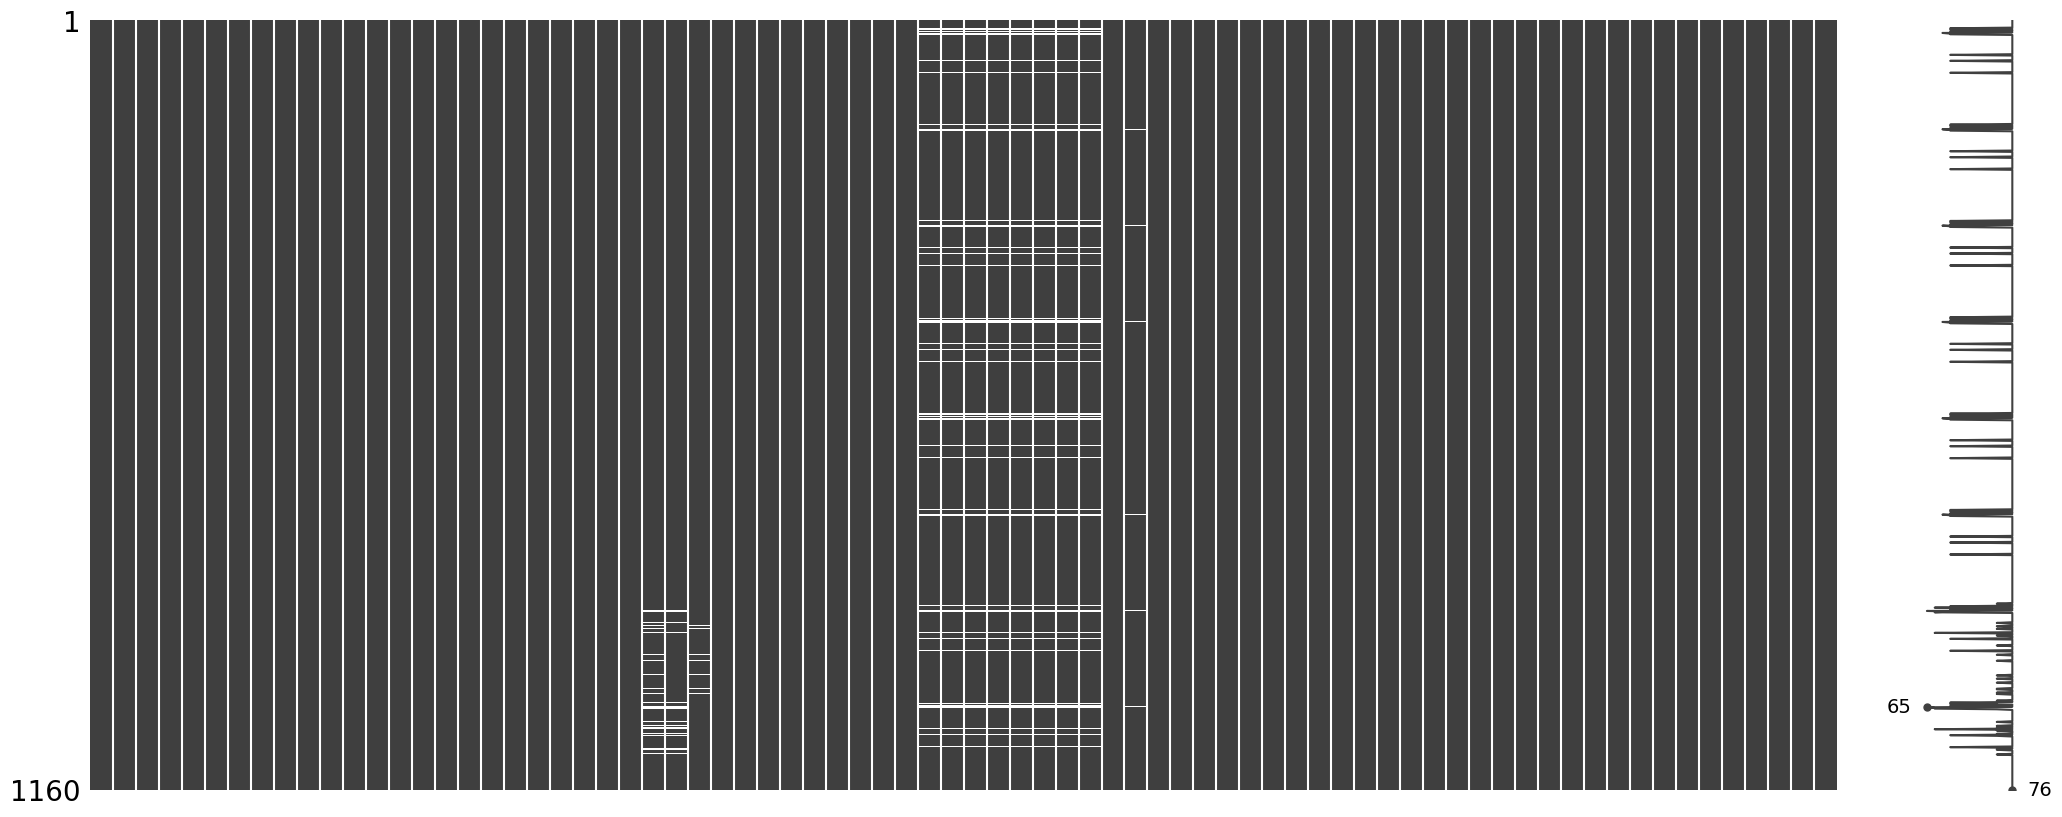

In [27]:
msno.matrix(dataset)

In [28]:
dataset

,dt_placement,year,month,year_lc,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,rainfall,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,year_biovars,dt_weather_acc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lst_min_prev_month,lst_max_prev_month,rainfall_acc_prev_month
0,2025-01,2025,1,2024,0.500,0.866,nord,benoue,bibemi,adoumri,13.770202,9.240232,0.221611,-0.115693,-0.351430,0.115693,0.222415,-0.121217,-0.359687,0.121217,0.014312,0.018195,0.016413,0.018195,25.92,33.59,18.48,0.0192,11525.50,1189.57,3.20,176.56,234.75,181.29,0.0,4.12,2812.42,750.98,1.79,48.90,24.03,1.21,0.0,5.97,31,36.0,30,12,12,3,5,8,2024,2024-12,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,15.04,36.74,0.6820
1,2025-01,2025,1,2024,0.500,0.866,nord,benoue,bibemi,bibemi,13.949181,9.263633,0.228015,-0.128318,-0.343611,0.128318,0.225038,-0.131594,-0.342374,0.131594,0.018079,0.017870,0.020000,0.017870,26.52,33.48,19.67,0.0304,27643.51,1357.07,2.87,173.78,293.25,180.81,0.0,93.00,6064.19,931.67,1.64,38.30,43.86,1.30,0.0,459.01,31,36.0,30,12,12,3,5,8,2024,2024-12,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,16.36,36.36,1.8785
2,2025-01,2025,1,2024,0.500,0.866,nord,benoue,bibemi,bide,13.972945,9.422292,0.228220,-0.101896,-0.347788,0.101896,0.231374,-0.096971,-0.352921,0.096971,0.015842,0.016957,0.016130,0.016957,26.47,33.48,19.52,0.0142,22660.82,1318.02,2.60,168.65,304.32,180.30,0.0,93.49,5555.85,719.27,1.24,31.22,20.07,1.64,0.0,330.45,31,36.0,30,12,12,3,5,8,2024,2024-12,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,16.77,35.59,4.7560
3,2025-01,2025,1,2024,0.500,0.866,nord,benoue,bibemi,dengui,13.642496,9.235656,0.248493,-0.103664,-0.337475,0.103664,0.249743,-0.108167,-0.342317,0.108167,0.020745,0.028386,0.021056,0.028386,25.28,32.46,18.10,0.0022,6789.43,1430.32,2.18,167.13,200.16,180.52,0.0,5.11,4263.62,736.59,1.17,24.83,14.39,1.04,0.0,7.22,31,36.0,30,12,12,3,5,8,2024,2024-12,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,15.28,37.50,2.6800
4,2025-01,2025,1,2024,0.500,0.866,nord,benoue,bibemi,djaloumi,13.994667,9.585190,0.215481,-0.051379,-0.305649,0.051379,0.217226,-0.045809,-0.312697,0.045809,0.023719,0.023485,0.028914,0.023485,26.90,32.86,21.00,0.0000,5443.51,2018.69,9.33,194.84,332.21,175.00,0.0,6.19,4805.14,451.44,9.71,47.64,77.27,7.15,0.0,7.46,31,36.0,30,12,12,3,5,8,2024,2024-12,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,18.33,35.54,2.2067
...,...,...,...,...,...,...,...,...,...,...,...,...

In [ ]:
# dataset.to_csv(f'../../data/{REGION}/CM_{REGION}_Dataset_X_{YEAR}.csv', encoding=enc)

In [29]:
dataset.to_csv(f'../../data/{REGION}/CM_{REGION}_Dataset_X_{YEAR}_08.csv', encoding=enc)